In [1]:
import sys
from pathlib import Path
NOTEBOOKS = Path.cwd()
NEURALNET = NOTEBOOKS.parents[0]
BAMBOO_SETUP = NEURALNET.parents[1]                           
sys.path.append(str((BAMBOO_SETUP/'src').resolve()))
import pandas as pd
pd.set_option('display.max_columns', None)  # Display all columns
pd.set_option('display.width', 1000)  # Set a larger width to fit the editor window

Z_OUTPUT_local = Path('/Users/antonett/Documents/HH Analysis/Z_OUTPUT_eos') 
Z_OUTPUT_eos = Path('/eos/user/a/anunezde/Z_OUTPUT_eos')
first_dir = str(NOTEBOOKS).split('/')[1]
Z_OUTPUT_current = Z_OUTPUT_eos if first_dir == 'afs' else Z_OUTPUT_local

%load_ext autoreload

In [8]:
%autoreload 2

# Setup a data handler

In [3]:
from NeuralNet.DataHandler import DataHandler
import logging
datahandler = DataHandler(
    workdir=Z_OUTPUT_eos/'2022_even_0815/Reco',
    tree_name='SL_res_2b_x',
    # total_inputs= NEURALNET / 'input/vars40_new.txt'
    log_level='debug'
)
total_df_unprep = datahandler.load_data()
total_df_unprep = datahandler.fix_column_names_mismatch(total_df_unprep)


Loading data...
	File: DY_dl_mll_10to50
	File: DY_dl_mll_50_0J
	File: DY_dl_mll_50_1J
	File: DY_dl_mll_50_2J
	File: bbWW_dl
	File: bbWW_sl
	File: bbtautau
	File: WW
	File: WZ
	File: ZZ
	File: Wjets_0J
	File: Wjets_1J
	File: Wjets_2J
	File: tWminus_dl
	File: tWminus_sl
	File: tbarWplus_dl
	File: tbarWplus_sl
	File: TTbar_dl
	File: TTbar_sl
	Total_df:
             event    gen_Weight  nAK4  nAK4_btag  nAK8_btag     lep0_pt  lep0_eta  lep0_phi  ak4_jet0_pt  ak4_jet0_eta  ak4_jet0_phi  ak4_jet1_pt  ak4_jet1_eta  ak4_jet1_phi  ak4_jet2_pt  ak4_jet2_eta  ak4_jet2_phi  ak4_btag0_pt  ak4_btag0_eta  ak4_btag0_phi  ak4_btag1_pt  ak4_btag1_eta  ak4_btag1_phi      met_pt   met_phi    bjets_mbb  bjets_dPhi  bjets_dPhi_abs  bjets_dEta  bjets_dEta_abs  bjets_dR  bjets_pt_bb    bjet0_pt    bjet1_pt  bjets_mean_pt  trijet_mInv   trijet_pt  trijet_pt_rat     blnu_mT     blnu_pt  trijet_bijet_dR  trijet_bijet_dPhi  trijet_bijet_dEta  bjet_bijet_dR  bjet_bijet_dPhi  bjet_bijet_dEta       all_sT  all_sT_5

In [4]:
datahandler.data_inspection(total_df_unprep)
total_df = datahandler.preprocess_data(total_df_unprep)
datahandler.data_inspection(total_df)


Data inspection ... 
	Duplicate events:
		Number of duplicate events found: 39203
	Negative genWeights:
		Number of events with negative genWeights: 5165
	Null Values (i.e NaN, None):
		No events with null values found.
	Additional checks on numeric features only:
		No events with inf values found.
		No events with features larger than abs(10000.0) found.

Preprocessing data ...
	Dropping exact duplicates if any ...
	Removing events with negative weights ...

Data inspection ... 
	Duplicate events:
		No duplicate events found.
	Negative genWeights:
		No events with negative genWeights found.
	Null Values (i.e NaN, None):
		No events with null values found.
	Additional checks on numeric features only:
		No events with inf values found.
		No events with features larger than abs(10000.0) found.


In [5]:
datahandler = DataHandler(
    workdir=Z_OUTPUT_eos/'2022_even_1013/Reco',
    tree_name='SL_res_2b_x',
    # total_inputs= NEURALNET / 'input/vars40_new.txt'
    log_level='info'
)
total_df_unprep = datahandler.load_data()
total_df_unprep = datahandler.fix_column_names_mismatch(total_df_unprep)
total_df_unprep


Loading data...


,event,run,luminosityBlock,genWeight,bunchCrossing,genTtbarId,lep0_pt,lep0_eta,lep0_phi,ak4_jet0_pt,ak4_jet0_eta,ak4_jet0_phi,ak4_jet1_pt,ak4_jet1_eta,ak4_jet1_phi,ak4_jet2_pt,ak4_jet2_eta,ak4_jet2_phi,ak4_btag0_pt,ak4_btag0_eta,ak4_btag0_phi,ak4_btag1_pt,ak4_btag1_eta,ak4_btag1_phi,met_pt,met_phi,nAK4,nAK4_btag,nAK4_nonbtag,nAK8_btag,bjets_mbb,bjets_dPhi,bjets_dPhi_abs,bjets_dEta,bjets_dEta_abs,bjets_dR,bjets_pt_bb,bjet0_pt,bjet1_pt,bjets_mean_pt,trijet_mInv,trijet_pt,trijet_pt_rat,blnu_mT,blnu_pt,trijet_bijet_dR,trijet_bijet_dPhi,trijet_bijet_dEta,bjet_bijet_dR,bjet_bijet_dPhi,bjet_bijet_dEta,all_sT,all_sT_50_cut,all_mInv,all_mT,all_jets_HT,all_pt,mjj,WW_mInv,File,Process
245116,18,1,1,3.805950,4294967295,151,89.622681,1.105957,-2.818848,172.5000,1.684570,0.624268,111.3750,1.175537,-1.235596,70.37500,0.964478,1.242432,172.50000,1.684570,0.624268,70.375000,0.964478,1.242432,116.074379,-2.936035,4,2,2,0,111.787468,-0.618164,0.618164,-0.720093,0.720093,0.949031,233.442108,70.375000,172.50000,121.437500,275.532318,173.572144,0.559403,315.133392,176.526657,1.441196,-1.164057,0.849716,2.027832,-1.962857,0.509210,586.353310,559.947060,697.857056,698.050232,380.656250,16.421644,41.493786,310.004181,tbarWplus_dl,tW
2242769,22,1,1,337.046997,4294967295,200,24.002106,-1.138565,0.132206,257.7500,-1.424072,-1.596436,94.8750,0.773926,1.199707,80.68750,1.667236,1.161865,257.75000,-1.424072,-1.596436,37.687500,1.211914,2.004883,65.833290,-1.534180,6,2,4,0,393.151337,2.681867,2.681867,2.635986,2.635986,3.760430,224.598801,37.687500,257.75000,147.718750,114.136292,203.058990,0.952211,406.004089,320.889313,0.140181,-0.136447,0.032135,0.824454,-0.822567,-0.055745,657.679146,562.833290,1253.854858,1255.707031,567.843750,68.177055,84.452141,351.268646,TTbar_sl,ttbar
16422,32,1,1,0.033119,4294967295,53,65.667160,1.346191,1.424072,192.0000,-0.145477,-1.602783,125.8125,0.816772,1.625244,50.75000,-0.764038,-0.813354,192.00000,-0.145477,-1.602783,50.750000,-0.764038,-0.813354,32.159973,2.111816,4,2,2,0,101.529617,-0.789429,0.789429,-0.618561,0.618561,1.002903,230.573227,50.750000,192.00000,121.375000,414.172607,91.249809,0.259301,221.209976,62.258396,2.308760,-2.306782,0.095544,3.132029,-2.781621,-1.439511,500.483383,434.229660,644.934692,645.593750,402.656250,29.164007,122.545013,199.450302,bbWW_sl,HH_bbWW
506544,36,1,1,81.103897,4294967295,242,67.785812,0.904053,2.238770,156.3750,-1.606689,-1.665039,81.3125,1.302246,0.167908,61.37500,-0.245758,-1.079590,81.31250,1.302246,0.167908,57.187500,-0.330811,-2.950195,183.191925,1.643311,5,2,3,0,186.289108,-3.118103,3.118103,1.633057,1.633057,3.519864,24.178112,81.312500,57.18750,69.250000,255.434219,224.622360,0.816994,389.353455,250.756989,0.255890,0.255418,0.015531,1.784749,1.447144,1.044559,633.727737,607.227737,1012.982605,1014.184021,382.750000,49.349865,158.995483,677.798035,TTbar_dl,ttbar
16423,42,1,1,0.033119,4294967295,10053,36.858803,0.859253,0.675903,107.0625,1.249756,0.425049,100.6875,2.201172,-2.758301,69.25000,1.812744,0.727173,100.68750,2.201172,-2.758301,66.937500,1.660645,-1.680908,17.724852,-3.136719,5,2,3,0,96.761787,1.077393,1.077393,0.540527,0.540527,1.205382,144.923660,100.687500,66.93750,83.812500,207.233261,143.871246,0.591454,212.537613,83.649582,0.651851,0.378334,0.530823,2.229081,2.224385,0.144626,425.693029,343.937500,503.722900,505.653351,371.109375,44.142178,58.874733,173.004791,bbWW_sl,HH_bbWW
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37979,744899478,1,144333,83745.546875,4294967295,53,59.665302,-1.757812,0.698730,202.2500,-1.348389,-1.258057,107.3750,-0.597656,2.217285,48.09375,-1.324219,-1.848633,48.09375,-1.324219,-1.848633,32.312500,-1.132080,2.531738,58.569748,2.203125,5,2,3,0,65.643822,1.902814,1.902814,0.192139,0.192139,1.912490,48.415188,32.312500,48.09375,40.203125,

In [6]:
datahandler.data_inspection(total_df_unprep)
total_df = datahandler.preprocess_data(total_df_unprep)
datahandler.data_inspection(total_df)


Data inspection ... 
	Duplicate events:
		Number of duplicate events found: 8747
	Negative genWeights:
		Number of events with negative genWeights: 14290
	Null Values (i.e NaN, None):
		No events with null values found.
	Additional checks on numeric features only:
		No events with inf values found.
		No events with features larger than abs(10000.0) found.

Preprocessing data ...
	Dropping exact duplicates if any ...
	Removing events with negative weights ...

Data inspection ... 
	Duplicate events:
		No duplicate events found.
	Negative genWeights:
		No events with negative genWeights found.
	Null Values (i.e NaN, None):
		No events with null values found.
	Additional checks on numeric features only:
		No events with inf values found.
		No events with features larger than abs(10000.0) found.


In [43]:
%autoreload 2

In [44]:
datahandler.data_summary(total_df)


Data summary (of numeric features and using only finite values) ...


	Stats summary:
		                       count    mean     std      min     25%     50%     75%      max
		lep0_pt            2367082.0   63.37   41.83    15.00   35.96   52.19   77.82  1376.13
		lep0_eta           2367082.0    0.00    1.08    -2.50   -0.79    0.00    0.79     2.50
		lep0_phi           2367082.0   -0.00    1.82    -3.14   -1.58   -0.01    1.57     3.14
		ak4_jet0_pt        2367082.0  139.43   86.43    26.58   87.56  116.88  162.00  2696.00
		ak4_jet0_eta       2367082.0   -0.00    1.13    -2.40   -0.86    0.00    0.85     2.40
		ak4_jet0_phi       2367082.0    0.00    1.81    -3.14   -1.57   -0.00    1.57     3.14
		ak4_jet1_pt        2367082.0   91.23   49.20    25.36   60.69   79.75  107.31  1953.00
		ak4_jet1_eta       2367082.0    0.00    1.14    -2.40   -0.86   -0.00    0.86     2.40
		ak4_jet1_phi       2367082.0    0.00    1.82    -3.14   -1.57    0.00    1.58     3.14
		ak4_jet2_pt        2367082.0   62.87   29.73    25.02   43.31   55.94   74.00  1119.00
		ak4

Class distribution:
ttbar          2000000
tW              351813
DY               14769
HH_bbtautau      11089
WJets             6580
HH_bbWW           4388
VV                1453
Name: Process, dtype: int64


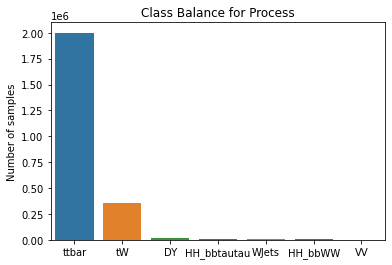

In [42]:
datahandler.check_class_balance(total_df_unprep, 'Process')

2024-10-25 11:02:07,801 - post_processing.NN.DataHandler - INFO - 
Plotting feature distributions ...


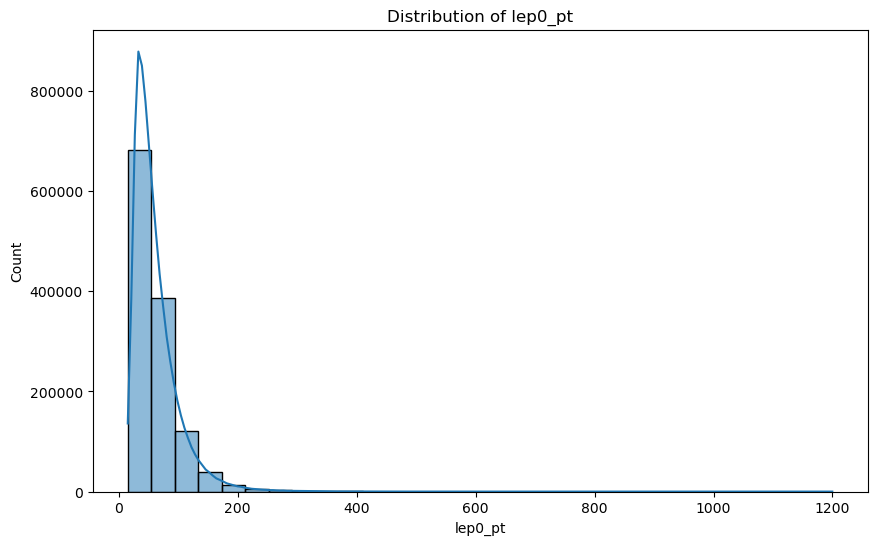

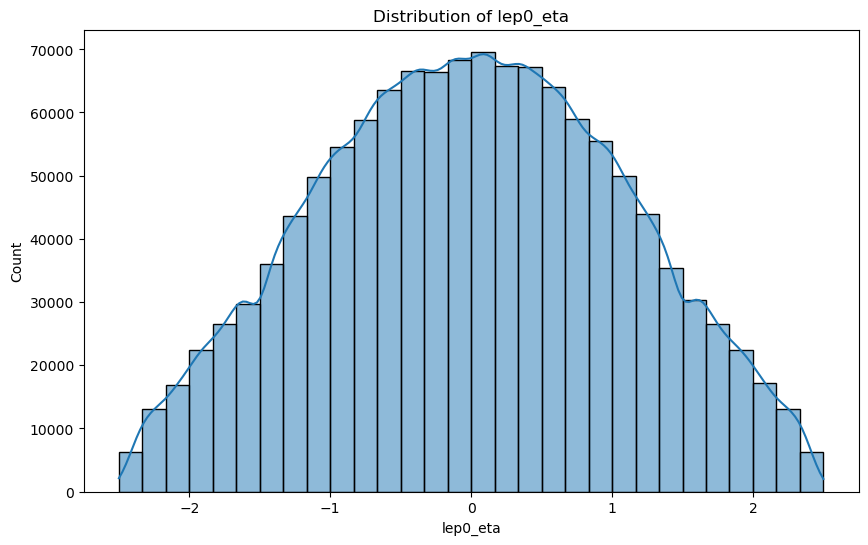

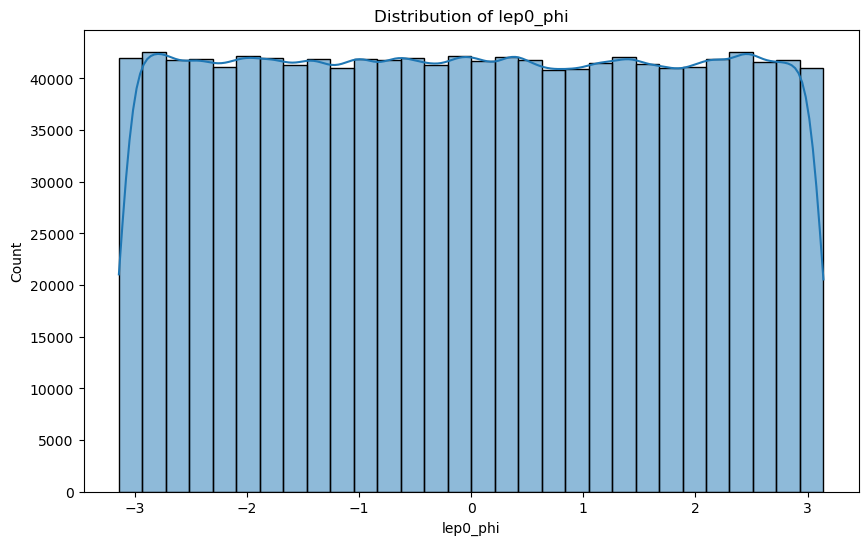

In [8]:
datahandler.plot_feature_distribution(total_df_unprep, columns=['lep0_pt', 'lep0_eta', 'lep0_phi'])

In [13]:
df_cleaned = datahandler.detect_and_remove_outliers(total_df_unprep)

2024-10-25 11:06:24,777 - post_processing.NN.DataHandler - INFO - 
Detecting outliers using zscore method...
2024-10-25 11:06:26,439 - post_processing.NN.DataHandler - INFO - Found 273523 outliers. Removed from dataset.


# Outliers

In [15]:
from scipy.stats import zscore
import numpy as np
df_foo = datahandler.extract_numeric_features_only(total_df_unprep)
z_scores_pm = np.abs(zscore(df_foo, nan_policy='omit'))
z_scores = np.abs(z_scores_pm)
threshold = 5
outlier_condition = z_scores > threshold            # Condition on parent df
# outlier_condition.sum().to_frame().T
outlier_rows_bool=outlier_condition.any(axis=1)     # Column of boolean on rows of parent df
df_outlier = df_foo[outlier_rows_bool]              # Child df of rows with outliers
df_outlier

Non-numerical columns excluded: Index([], dtype='object')


,nAK4,nAK4_btag,nAK8_btag,lep0_pt,lep0_eta,lep0_phi,ak4_jet0_pt,ak4_jet0_eta,ak4_jet0_phi,ak4_jet1_pt,ak4_jet1_eta,ak4_jet1_phi,ak4_jet2_pt,ak4_jet2_eta,ak4_jet2_phi,ak4_btag0_pt,ak4_btag0_eta,ak4_btag0_phi,ak4_btag1_pt,ak4_btag1_eta,ak4_btag1_phi,met_pt,met_phi,bjets_mbb,bjets_dPhi,bjets_dPhi_abs,bjets_dEta,bjets_dEta_abs,bjets_dR,bjets_pt_bb,bjet0_pt,bjet1_pt,bjets_mean_pt,trijet_mInv,trijet_pt,trijet_pt_rat,blnu_mT,blnu_pt,trijet_bijet_dR,trijet_bijet_dPhi,trijet_bijet_dEta,bjet_bijet_dR,bjet_bijet_dPhi,bjet_bijet_dEta,all_sT,all_sT_50_cut,all_mInv,all_mT,all_jets_HT,all_pt,mjj,WW_mInv
67737,4,2,0,23.006124,1.428223,1.028809,389.000,-0.978149,0.902466,120.6875,0.575195,0.876465,80.6250,1.624512,-1.102783,389.000,-0.978149,0.902466,120.68750,0.575195,0.876465,128.377243,-2.116211,374.620300,0.026001,0.026001,1.553345,1.553345,1.553562,509.656342,120.68750,389.000,254.843750,697.709045,387.609619,0.781323,298.387268,22.655346,2.627644,-1.473792,-2.175419,3.084597,-1.699405,-2.574250,768.164618,718.689743,1073.020874,1147.621094,616.781250,407.014191,88.669304,300.002533
196008,7,2,0,54.439014,-0.057936,0.358711,242.000,1.129150,-2.119629,233.8750,1.285156,1.390137,206.6250,1.209961,2.106445,233.875,1.285156,1.390137,206.62500,1.209961,2.106445,237.895233,-0.630859,166.691055,-0.716309,0.716309,-0.075195,0.075195,0.720245,412.658813,206.62500,233.875,220.250000,642.392151,297.922638,0.574309,640.145325,305.177979,0.956356,0.696596,0.655265,2.016020,1.960276,0.470803,1186.584248,1110.459248,1578.332031,1579.972046,894.250000,71.968384,348.062897,687.450378
51304,6,2,0,58.720802,2.258301,-2.201172,559.500,-0.094055,1.557617,535.0000,0.257446,-1.569580,83.0000,1.799316,2.147949,535.000,0.257446,-1.569580,59.71875,1.354492,-0.155304,82.911667,-1.185547,312.097473,-1.414276,1.414276,1.097046,1.097046,1.789885,547.496155,59.71875,535.000,297.359375,646.147888,620.128296,0.883098,820.256470,659.275269,0.191325,0.094212,0.166521,2.074769,1.786304,1.055358,1439.413719,1378.851219,1783.569824,1783.753296,1297.781250,25.588148,489.651825,966.234497
718672,7,2,0,71.063538,0.234440,0.021563,251.750,-0.444519,-1.957764,224.7500,0.260498,1.845703,203.3750,-0.820068,-2.656738,203.375,-0.820068,-2.656738,182.37500,0.174438,0.707764,241.785843,0.631958,435.714691,-2.918683,2.918683,-0.994507,0.994507,3.083465,47.711166,203.37500,182.375,192.875000,266.383667,528.757202,0.943577,498.439453,482.619507,0.340940,0.251304,-0.230404,0.871822,0.703005,-0.515614,1356.958755,1331.318130,1521.043457,1521.138550,1044.109375,17.006302,86.439621,653.012756
70984,4,2,0,268.401550,-0.452591,-2.371399,252.500,0.103394,1.476318,189.8750,2.135254,-0.219391,46.1250,-0.636597,-0.948364,252.500,0.103394,1.476318,46.12500,-0.636597,-0.948364,45.725433,2.475098,219.557205,-2.424683,2.424683,0.739990,0.739990,2.535088,219.828308,252.50000,46.125,149.312500,662.613342,287.993469,0.610965,366.316925,281.306244,1.185645,-1.062468,-0.526228,2.756212,-1.656213,-2.203103,831.626984,710.776550,1338.976807,1339.367676,517.500000,32.357887,209.042908,954.933899
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7209,4,2,0,153.874023,1.693939,0.759720,175.125,-1.132812,2.863770,172.8750,1.324951,0.304932,155.2500,0.221649,-1.778809,175.125,-1.132812,2.863770,155.25000,0.221649,-1.778809,48.138306,1.496338,342.843231,-1.640607,1.640607,1.354462,1.354462,2.127477,225.783859,155.25000,175.125,165.187500,768.020508,200.954483,0.453047,764.604370,208.915558,0.861935,0.861863,-0.011159,1.391065,1.383533,-0.144572,820.699829,772.561523,1561.092651,1561.154907,618.687500,13.938810,627.682190,998.456970
7057,4,2,0,17.456400,-0.814575,1.898682,301.500,0.852539,-3.029297,298.5000,0.205719,-0.454529,163.5000,0.143616,2.959961,301.500,0.852539,-3.029297,298.50000,0.205719,-0.454529,259.962189,0.216949,613.126831,-2.574768,2.574768,-

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot in separte plots
def plot_outlier_distribution_for_feature(df_outlier, column):
    df_outlier_values_shown_only = df_outlier[outlier_condition]    # Condition on child df
    row_mask_for_column = df_outlier_values_shown_only[column].notna()
    outliers_for_column = df_outlier_values_shown_only[row_mask_for_column][column]
    fig, ax = plt.subplots()
    sns.histplot(outliers_for_column, ax=ax)
    return outliers_for_column

plot_outlier_distribution_for_feature(df_outlier, 'blnu_pt')
plot_outlier_distribution_for_feature(df_outlier, 'lep0_pt')
plot_outlier_distribution_for_feature(df_outlier, 'bjets_mbb')

        nAK4  nAK4_btag  nAK8_btag    lep0_pt  lep0_eta  lep0_phi  ak4_jet0_pt  ak4_jet0_eta  ak4_jet0_phi  ak4_jet1_pt  ak4_jet1_eta  ak4_jet1_phi  ak4_jet2_pt  ak4_jet2_eta  ak4_jet2_phi  ak4_btag0_pt  ak4_btag0_eta  ak4_btag0_phi  ak4_btag1_pt  ak4_btag1_eta  ak4_btag1_phi  met_pt  met_phi    bjets_mbb  bjets_dPhi  bjets_dPhi_abs  bjets_dEta  bjets_dEta_abs  bjets_dR  bjets_pt_bb  bjet0_pt  bjet1_pt  bjets_mean_pt  trijet_mInv   trijet_pt  trijet_pt_rat     blnu_mT     blnu_pt  trijet_bijet_dR  trijet_bijet_dPhi  trijet_bijet_dEta  bjet_bijet_dR  bjet_bijet_dPhi  bjet_bijet_dEta       all_sT  all_sT_50_cut  all_mInv  all_mT  all_jets_HT      all_pt  mjj  WW_mInv
67737    NaN        NaN        NaN        NaN       NaN       NaN          NaN           NaN           NaN          NaN           NaN           NaN          NaN           NaN           NaN           NaN            NaN            NaN           NaN            NaN            NaN     NaN      NaN          NaN         NaN        

/Users/antonett/anaconda3/envs/myenv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


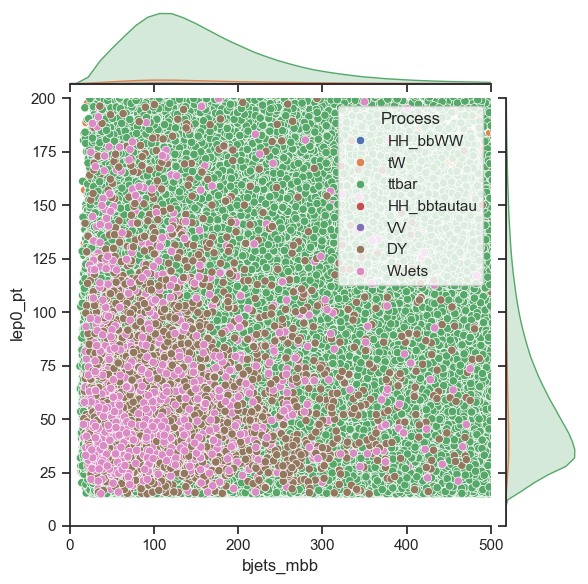

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.jointplot(df, x='bjets_mbb', y='lep0_pt', hue="Process")
plt.xlim(0, 500)
plt.ylim(0, 200)
plt.show()

Processes(7): ['HH_bbWW' 'tW' 'ttbar' 'HH_bbtautau' 'VV' 'DY' 'WJets']
0: HH_bbWW
1: tW
2: ttbar
3: HH_bbtautau
4: VV
5: DY
6: WJets


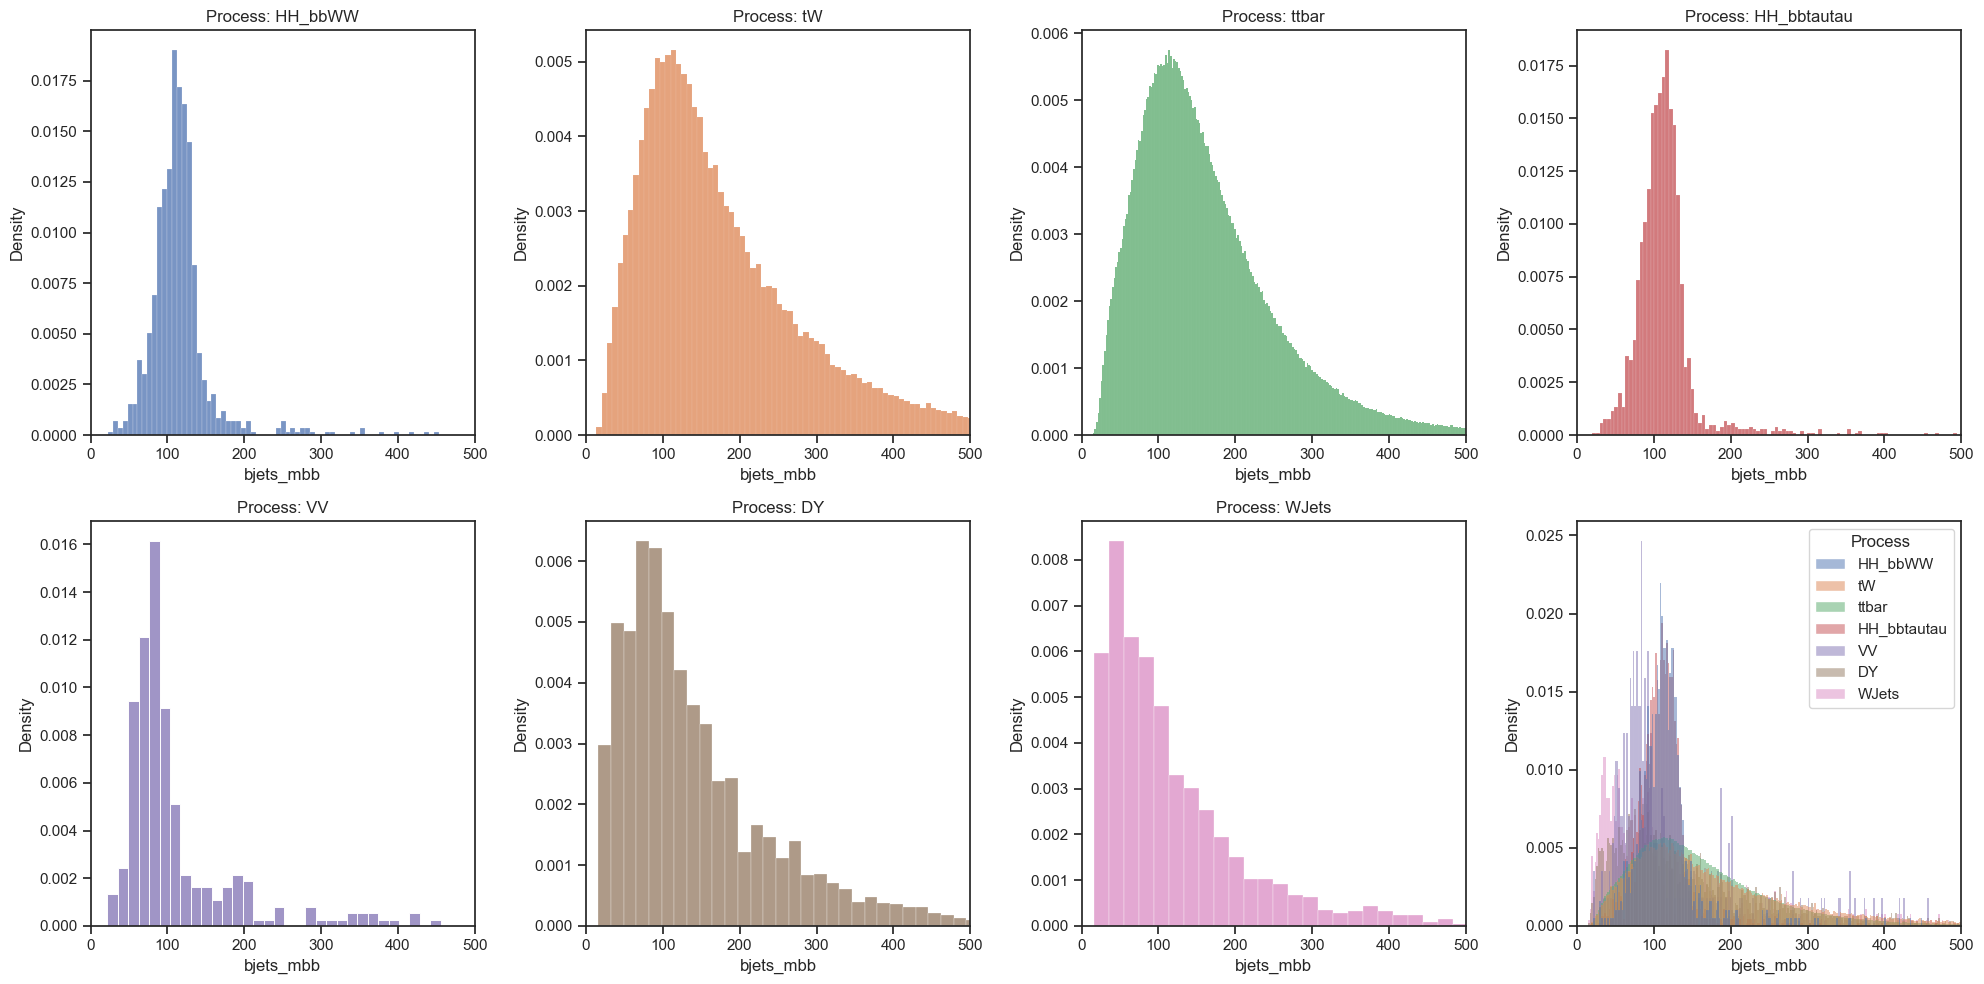

In [157]:
processes = df['Process'].unique()
n_processes = len(processes)
print(f"Processes({n_processes}): {processes}")
# Create a figure with multiple subplots
fig, axes = plt.subplots(nrows=2,ncols=4, figsize=(20, 10))

axes = axes.flatten()
for i, process in enumerate(processes):
    print(f"{i}: {process}")
    ax = axes[i]
    sns.histplot(df[df['Process'] == process], x='bjets_mbb', stat='density', ax=ax, color=sns.color_palette()[i])
    ax.set_title(f'Process: {process}')
    ax.set_xlim((0, 500))

last_ax = axes[7]
sns.histplot(df, x='bjets_mbb', hue='Process', stat='density', ax=last_ax, common_norm=False, kde=False)
last_ax.set_xlim((0, 500))

plt.tight_layout()

<Axes: xlabel='bjets_dR', ylabel='Proportion'>

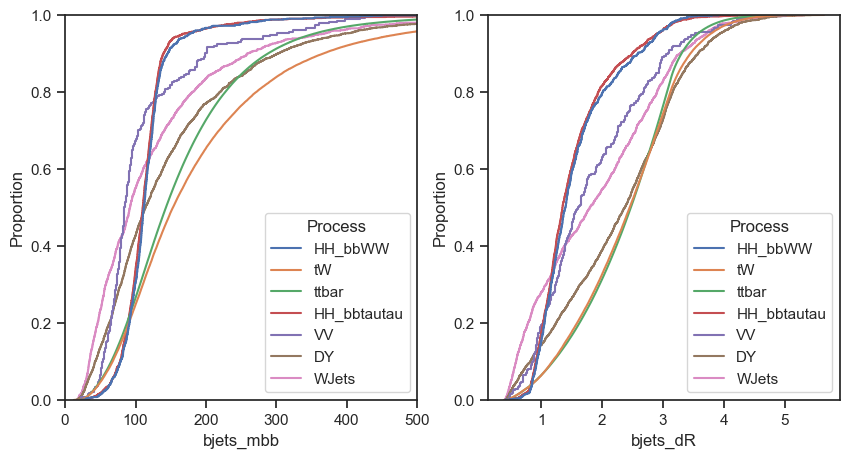

In [167]:
fig, axes = plt.subplots(ncols=2, figsize=(10, 5))
sns.ecdfplot(df, x='bjets_mbb', hue='Process', ax=axes[0])  # Also: sns.displot(df, x='bjets_dR', hue='Process', kind='ecdf')
axes[0].set_xlim((0, 500))
sns.ecdfplot(df, x='bjets_dR', hue='Process', ax=axes[1])